In [1]:
!nvidia-smi


Mon Feb  2 15:16:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip -q install ultralytics roboflow opencv-python pillow pyyaml matplotlib pandas tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 68.8 MB/s eta 0:00:00


In [3]:
import os

# ✅ Put your key here (better: use Colab secrets)
os.environ["ROBOFLOW_API_KEY"] = "6PWqdRK2WP8m7rhS9qRb"

print("✅ ROBOFLOW_API_KEY set:", "ROBOFLOW_API_KEY" in os.environ)


✅ ROBOFLOW_API_KEY set: True


In [4]:
from roboflow import Roboflow
import os

workspace_name = "daffodil-international-university-s5vpr"
project_name   = "merged-voyoh"
version_number = 1

rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])
project = rf.workspace(workspace_name).project(project_name)

# ✅ This downloads to a folder and returns an object with `.location`
dataset = project.version(version_number).download("yolov8")

DATASET_DIR = dataset.location
print("✅ Downloaded dataset to:", DATASET_DIR)


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Merged--1 in yolov8:: 100%|██████████| 1798/1798 [00:00<00:00, 9566.39it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Downloaded dataset to: /content/Merged--1


In [5]:
import os, glob, yaml

yaml_candidates = glob.glob(os.path.join(DATASET_DIR, "*.yaml"))
print("YAML candidates:", yaml_candidates)

assert len(yaml_candidates) > 0, "❌ No YAML file found in dataset root."

DATA_YAML = yaml_candidates[0]
print("✅ Using data.yaml:", DATA_YAML)

with open(DATA_YAML, "r") as f:
    data = yaml.safe_load(f)

print("✅ Keys in yaml:", list(data.keys()))
print("\n--- data.yaml ---\n")
print(open(DATA_YAML, "r").read())


YAML candidates: ['/content/Merged--1/data.yaml']
✅ Using data.yaml: /content/Merged--1/data.yaml
✅ Keys in yaml: ['names', 'nc', 'roboflow', 'test', 'train', 'val']

--- data.yaml ---

names:
- A to Z
- A-C
- A-Cal D
- A-Calm
- AMycin
- ATOZ Senior
- ATV
- AU-20
- Abdalan
- Abdolax
- Abecab
- Abetis Plus
- Abetis
- Ace Plus
- Ace Power
- Ace XR
- Ace
- Acelex
- Acetram
- Acifix
- Aciphin
- Acitrin-L
- Acliz Plus
- Acos
- Acron
- Actrapid
- Adam 33
- Adlock
- Adora
- Adovas
- Advel
- Aeron
- Afix
- Afrin
- Airflow
- Alagra
- Alanil
- Alarup
- Alatrol
- Albasine
- Alben DS
- Alcet
- Alervil
- Alestor
- Alex
- Alfumax ER
- Algecal D
- Algecal DX
- Algecal
- Algicid DX
- Algicid
- Algin
- Algita D
- Alice
- Alkanon
- Allygest
- Almex
- Alneed
- Alovera
- Alphapress
- Alve
- Ambronil
- Ambrox
- Amdocal Plus
- Amdocal
- Amikacin
- Amilin Plus
- Amilin
- Amira
- Amit
- Amitriptyline
- Amlevo
- Amlocard
- Amlodipine
- Anadol
- Anaflex Max
- Anclog
- Ancor
- Androcap
- Anfree
- Angenta
- Angil

In [6]:
# names can be list OR dict depending on Roboflow export
names = data["names"]
if isinstance(names, dict):
    CLASS_NAMES = [names[i] for i in range(len(names))]
else:
    CLASS_NAMES = list(names)

print("✅ Number of classes:", len(CLASS_NAMES))
print("✅ First 30 class names:", CLASS_NAMES[:30])


✅ Number of classes: 1445
✅ First 30 class names: ['A to Z', 'A-C', 'A-Cal D', 'A-Calm', 'AMycin', 'ATOZ Senior', 'ATV', 'AU-20', 'Abdalan', 'Abdolax', 'Abecab', 'Abetis Plus', 'Abetis', 'Ace Plus', 'Ace Power', 'Ace XR', 'Ace', 'Acelex', 'Acetram', 'Acifix', 'Aciphin', 'Acitrin-L', 'Acliz Plus', 'Acos', 'Acron', 'Actrapid', 'Adam 33', 'Adlock', 'Adora', 'Adovas']


In [7]:
import glob, os

def count_split(split):
    img_dir = os.path.join(DATASET_DIR, split, "images")
    lbl_dir = os.path.join(DATASET_DIR, split, "labels")
    imgs = sorted(glob.glob(os.path.join(img_dir, "*")))
    lbls = sorted(glob.glob(os.path.join(lbl_dir, "*.txt")))
    return len(imgs), len(lbls), img_dir, lbl_dir

for split in ["train", "valid", "test"]:
    n_img, n_lbl, img_dir, lbl_dir = count_split(split)
    print(f"{split}: images={n_img} labels={n_lbl}")
    print("  img_dir:", img_dir)
    print("  lbl_dir:", lbl_dir)


train: images=622 labels=622
  img_dir: /content/Merged--1/train/images
  lbl_dir: /content/Merged--1/train/labels
valid: images=176 labels=176
  img_dir: /content/Merged--1/valid/images
  lbl_dir: /content/Merged--1/valid/labels
test: images=95 labels=95
  img_dir: /content/Merged--1/test/images
  lbl_dir: /content/Merged--1/test/labels


🖼 Image: /content/Merged--1/train/images/WhatsApp-Image-2023-04-12-at-12-23-44-PM_jpeg.rf.9429aaf9a461500f50b10555300547e1.jpg
📄 Label: /content/Merged--1/train/labels/WhatsApp-Image-2023-04-12-at-12-23-44-PM_jpeg.rf.9429aaf9a461500f50b10555300547e1.txt


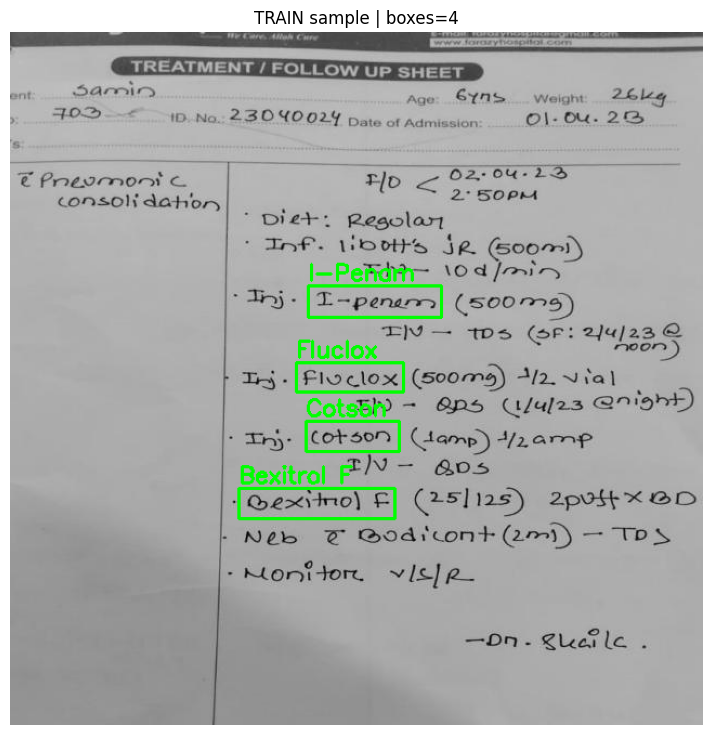

In [8]:
import random, os, glob
import cv2
import matplotlib.pyplot as plt

def yolo_to_xyxy(xc, yc, w, h, W, H):
    x1 = int((xc - w/2) * W)
    y1 = int((yc - h/2) * H)
    x2 = int((xc + w/2) * W)
    y2 = int((yc + h/2) * H)
    # clip
    x1 = max(0, min(W-1, x1))
    y1 = max(0, min(H-1, y1))
    x2 = max(0, min(W-1, x2))
    y2 = max(0, min(H-1, y2))
    return x1, y1, x2, y2

SPLIT = "train"
IMG_DIR = os.path.join(DATASET_DIR, SPLIT, "images")
LBL_DIR = os.path.join(DATASET_DIR, SPLIT, "labels")

images = sorted(glob.glob(os.path.join(IMG_DIR, "*")))
assert len(images) > 0, "❌ No images found in this split!"

img_path = random.choice(images)
stem = os.path.splitext(os.path.basename(img_path))[0]
lbl_path = os.path.join(LBL_DIR, stem + ".txt")

print("🖼 Image:", img_path)
print("📄 Label:", lbl_path)

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
H, W = img_rgb.shape[:2]

lines = []
if os.path.exists(lbl_path):
    with open(lbl_path, "r") as f:
        lines = [ln.strip().split() for ln in f if ln.strip()]

draw = img_rgb.copy()
for parts in lines:
    if len(parts) < 5:
        continue
    cls, xc, yc, bw, bh = parts[:5]
    cls = int(float(cls))
    xc, yc, bw, bh = map(float, (xc, yc, bw, bh))
    x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, bw, bh, W, H)

    cv2.rectangle(draw, (x1,y1), (x2,y2), (0,255,0), 2)
    name = CLASS_NAMES[cls] if 0 <= cls < len(CLASS_NAMES) else str(cls)
    cv2.putText(draw, name, (x1, max(20, y1-5)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

plt.figure(figsize=(9,9))
plt.imshow(draw)
plt.axis("off")
plt.title(f"{SPLIT.upper()} sample | boxes={len(lines)}")
plt.show()


In [9]:
import os, shutil, glob, yaml

SRC_DIR = DATASET_DIR  # your roboflow dataset root
DST_DIR = "/content/Merged_ROI_1class"
os.makedirs(DST_DIR, exist_ok=True)

print("SRC:", SRC_DIR)
print("DST:", DST_DIR)


SRC: /content/Merged--1
DST: /content/Merged_ROI_1class


In [10]:
import os, glob, shutil

def ensure_dirs(base, split):
    os.makedirs(os.path.join(base, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(base, split, "labels"), exist_ok=True)

def rewrite_labels_to_single_class(src_lbl_path, dst_lbl_path):
    # YOLO label format: cls xc yc w h [optional extras]
    out_lines = []
    with open(src_lbl_path, "r") as f:
        for ln in f:
            ln = ln.strip()
            if not ln:
                continue
            parts = ln.split()
            if len(parts) < 5:
                continue
            # force class id to 0, keep bbox coords
            out_lines.append("0 " + " ".join(parts[1:5]))
    with open(dst_lbl_path, "w") as f:
        f.write("\n".join(out_lines) + ("\n" if out_lines else ""))

for split in ["train", "valid", "test"]:
    ensure_dirs(DST_DIR, split)

    src_img_dir = os.path.join(SRC_DIR, split, "images")
    src_lbl_dir = os.path.join(SRC_DIR, split, "labels")

    dst_img_dir = os.path.join(DST_DIR, split, "images")
    dst_lbl_dir = os.path.join(DST_DIR, split, "labels")

    imgs = sorted(glob.glob(os.path.join(src_img_dir, "*")))
    print(split, "images:", len(imgs))

    for img_path in imgs:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(src_lbl_dir, stem + ".txt")

        # copy image
        shutil.copy2(img_path, os.path.join(dst_img_dir, os.path.basename(img_path)))

        # rewrite label (if exists)
        if os.path.exists(lbl_path):
            rewrite_labels_to_single_class(lbl_path, os.path.join(dst_lbl_dir, stem + ".txt"))
        else:
            # create empty label file
            open(os.path.join(dst_lbl_dir, stem + ".txt"), "w").close()

print("✅ Done conversion to single class.")


train images: 622
valid images: 176
test images: 95
✅ Done conversion to single class.


In [11]:
import os, yaml

DATA_YAML_1C = os.path.join(DST_DIR, "data.yaml")
data_1c = {
    "path": DST_DIR,
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 1,
    "names": ["roi"]
}

with open(DATA_YAML_1C, "w") as f:
    yaml.safe_dump(data_1c, f, sort_keys=False)

print("✅ New data.yaml:", DATA_YAML_1C)
print(open(DATA_YAML_1C).read())


✅ New data.yaml: /content/Merged_ROI_1class/data.yaml
path: /content/Merged_ROI_1class
train: train/images
val: valid/images
test: test/images
nc: 1
names:
- roi



In [12]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=DATA_YAML_1C,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    project="roi_runs_1class",
    name="yolov8n_roi"
)


Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Merged_ROI_1class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_roi, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a004989fdd0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [13]:
import glob, os

cands = glob.glob("**/best.pt", recursive=True)
print("Found best.pt files:", len(cands))
for p in cands[:50]:
    print(p)

assert len(cands) > 0, "❌ No best.pt found anywhere. Training likely did not finish."
BEST = sorted(cands, key=os.path.getmtime)[-1]
print("\n✅ Using latest best.pt:", BEST)



Found best.pt files: 1
runs/detect/roi_runs_1class/yolov8n_roi/weights/best.pt

✅ Using latest best.pt: runs/detect/roi_runs_1class/yolov8n_roi/weights/best.pt


In [14]:
import glob, os
from ultralytics import YOLO

best = "runs/detect/roi_runs_1class/yolov8n_roi/weights/best.pt"
assert os.path.exists(best), "❌ best.pt not found."
roi_model_1c = YOLO(best)

res = roi_model_1c.val(data=DATA_YAML_1C, split="test", device=0)
print("mAP50:", float(res.box.map50))
print("mAP50-95:", float(res.box.map))


Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1066.1±573.3 MB/s, size: 36.9 KB)
val: Scanning /content/Merged_ROI_1class/test/labels... 95 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 95/95 2.6Kit/s 0.0s
val: New cache created: /content/Merged_ROI_1class/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.5it/s 2.4s
                   all         95        402      0.827      0.846      0.869      0.515
Speed: 4.2ms preprocess, 5.4ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/detect/val
mAP50: 0.8686145661825107
mAP50-95: 0.5147516563790487


In [15]:
import glob, os
from ultralytics import YOLO

# Find latest best.pt
cands = glob.glob("/content/**/best.pt", recursive=True)
assert len(cands) > 0, "❌ best.pt not found anywhere."
BEST = sorted(cands, key=os.path.getmtime)[-1]
print("✅ Using best:", BEST)

roi_model = YOLO(BEST)


✅ Using best: /content/runs/detect/roi_runs_1class/yolov8n_roi/weights/best.pt


In [16]:
import os, glob
import cv2
import pandas as pd
from tqdm import tqdm

IMG_ROOT = "/content/Merged_ROI_1class/test/images"   # change to any folder of full images
OUT_ROOT = "/content/roi_pred_crops"
os.makedirs(OUT_ROOT, exist_ok=True)

imgs = sorted(glob.glob(os.path.join(IMG_ROOT, "*")))
print("✅ Images:", len(imgs))

rows = []
crop_id = 0

PAD = 0.08      # padding around ROI
CONF = 0.25     # detection confidence
MAX_DET = 50    # max boxes per image

for img_path in tqdm(imgs, desc="Detect + crop"):
    bgr = cv2.imread(img_path)
    if bgr is None:
        continue
    H, W = bgr.shape[:2]

    r = roi_model.predict(img_path, conf=CONF, device=0, verbose=False, max_det=MAX_DET)[0]
    boxes = r.boxes

    if boxes is None or len(boxes) == 0:
        continue

    for b in boxes:
        x1, y1, x2, y2 = b.xyxy[0].cpu().numpy().tolist()
        conf = float(b.conf[0].cpu().numpy())

        # padding
        bw = x2 - x1
        bh = y2 - y1
        px = PAD * bw
        py = PAD * bh

        x1p = int(max(0, x1 - px))
        y1p = int(max(0, y1 - py))
        x2p = int(min(W-1, x2 + px))
        y2p = int(min(H-1, y2 + py))

        if x2p <= x1p or y2p <= y1p:
            continue

        crop = bgr[y1p:y2p, x1p:x2p]
        crop_name = f"{os.path.splitext(os.path.basename(img_path))[0]}_pred_{crop_id:06d}.jpg"
        crop_path = os.path.join(OUT_ROOT, crop_name)
        cv2.imwrite(crop_path, crop)

        rows.append({
            "orig_image": img_path,
            "crop_path": crop_path,
            "conf": conf,
            "x1": x1p, "y1": y1p, "x2": x2p, "y2": y2p
        })
        crop_id += 1

df_pred = pd.DataFrame(rows)
CSV = os.path.join(OUT_ROOT, "roi_pred_crops_metadata.csv")
df_pred.to_csv(CSV, index=False)

print("✅ Saved crops:", len(df_pred))
print("✅ Saved CSV:", CSV)
df_pred.head()


✅ Images: 95


Detect + crop: 100%|██████████| 95/95 [00:01<00:00, 68.98it/s]

✅ Saved crops: 418
✅ Saved CSV: /content/roi_pred_crops/roi_pred_crops_metadata.csv


,orig_image,crop_path,conf,x1,y1,x2,y2
0,/content/Merged_ROI_1class/test/images/1586448...,/content/roi_pred_crops/158644895_882858708940...,0.748340,336,209,460,240
1,/content/Merged_ROI_1class/test/images/1586448...,/content/roi_pred_crops/158644895_882858708940...,0.621353,367,330,512,358
2,/content/Merged_ROI_1class/test/images/1586448...,/content/roi_pred_crops/158644895_882858708940...,0.323858,377,270,442,297
3,/content/Merged_ROI_1class/test/images/2746109...,/content/roi_pred_crops/274610921_174984107868...,0.710134,311,356,401,395
4,/content/Merged_ROI_1class/test/images/2746109...,/content/roi_pred_crops/274610921_174984107868...,0.435653,302,419,395,475


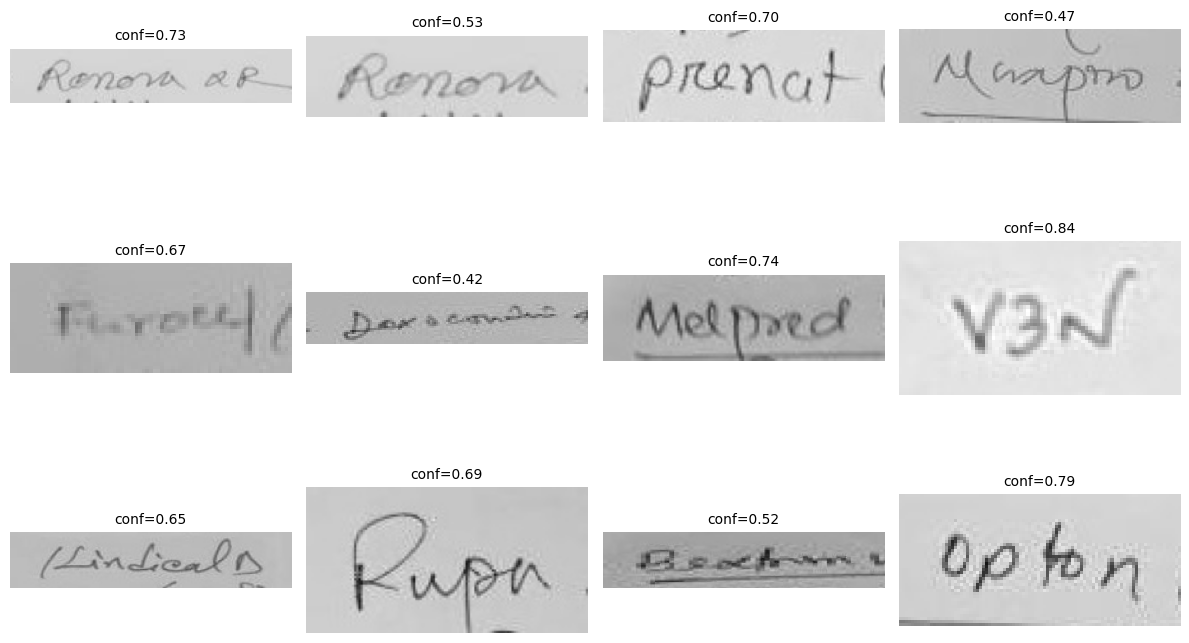

In [17]:
import random, cv2
import matplotlib.pyplot as plt

SHOW = 12
sample = df_pred.sample(min(SHOW, len(df_pred)), random_state=42).reset_index(drop=True)

plt.figure(figsize=(12, 8))
for i in range(len(sample)):
    p = sample.loc[i, "crop_path"]
    conf = sample.loc[i, "conf"]
    img = cv2.imread(p)
    if img is None:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(3, 4, i+1)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"conf={conf:.2f}", fontsize=10)

plt.tight_layout()
plt.show()


In [18]:
import os, glob
import cv2
import numpy as np

GT_ROOT = "/content/Merged_ROI_1class"   # 1-class dataset root (has images/labels)
# BUT we need the original dataset with real class names for mapping
ORIG_ROOT = "/content/Merged--1"         # original dataset with many class names
# If your original dataset path is different, change it.

# Use CLASS_NAMES from the original data.yaml (many classes)
import yaml
orig_yaml = os.path.join(ORIG_ROOT, "data.yaml")
with open(orig_yaml, "r") as f:
    d = yaml.safe_load(f)

names = d["names"]
if isinstance(names, dict):
    CLASS_NAMES_ORIG = [names[i] for i in range(len(names))]
else:
    CLASS_NAMES_ORIG = list(names)

print("✅ Original class count:", len(CLASS_NAMES_ORIG))

def yolo_to_xyxy_abs(xc, yc, w, h, W, H):
    x1 = (xc - w/2) * W
    y1 = (yc - h/2) * H
    x2 = (xc + w/2) * W
    y2 = (yc + h/2) * H
    return x1, y1, x2, y2

def load_gt_for_split(split):
    img_dir = os.path.join(ORIG_ROOT, split, "images")
    lbl_dir = os.path.join(ORIG_ROOT, split, "labels")

    gt_map = {}  # img_path -> list of (x1,y1,x2,y2,cls_id)
    imgs = sorted(glob.glob(os.path.join(img_dir, "*")))

    for img_path in imgs:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(lbl_dir, stem + ".txt")
        if not os.path.exists(lbl_path):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue
        H, W = img.shape[:2]

        boxes = []
        with open(lbl_path, "r") as f:
            for ln in f:
                ln = ln.strip()
                if not ln:
                    continue
                parts = ln.split()
                if len(parts) < 5:
                    continue
                cls = int(float(parts[0]))
                xc, yc, bw, bh = map(float, parts[1:5])
                x1, y1, x2, y2 = yolo_to_xyxy_abs(xc, yc, bw, bh, W, H)
                boxes.append((x1, y1, x2, y2, cls))

        if boxes:
            gt_map[img_path] = boxes

    return gt_map

# Load GT map for the split you are visualizing (your screenshot is from test)
gt_map_test = load_gt_for_split("test")
print("✅ GT images loaded:", len(gt_map_test))


✅ Original class count: 1445
✅ GT images loaded: 95


In [19]:
def iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    iw = max(0.0, inter_x2 - inter_x1)
    ih = max(0.0, inter_y2 - inter_y1)
    inter = iw * ih
    area_a = max(0.0, ax2-ax1) * max(0.0, ay2-ay1)
    area_b = max(0.0, bx2-bx1) * max(0.0, by2-by1)
    union = area_a + area_b - inter + 1e-9
    return inter / union

def match_pred_to_gt_name(orig_image_path, pred_xyxy, gt_map, iou_thr=0.3):
    # Find corresponding GT list for this image
    gts = gt_map.get(orig_image_path, [])
    if not gts:
        return None, 0.0

    best_iou = 0.0
    best_cls = None
    for (x1, y1, x2, y2, cls) in gts:
        i = iou_xyxy(pred_xyxy, (x1, y1, x2, y2))
        if i > best_iou:
            best_iou = i
            best_cls = cls

    if best_iou >= iou_thr and best_cls is not None and 0 <= best_cls < len(CLASS_NAMES_ORIG):
        return CLASS_NAMES_ORIG[best_cls], best_iou
    return None, best_iou


In [20]:
import pandas as pd

# IMPORTANT:
# df_pred["orig_image"] must point to ORIGINAL test image paths inside ORIG_ROOT/test/images
# If your df_pred orig_image points to /content/Merged_ROI_1class/test/images,
# we must map it to ORIG_ROOT/test/images by filename.

def to_orig_test_path(p):
    fn = os.path.basename(p)
    return os.path.join(ORIG_ROOT, "test", "images", fn)

df_pred = df_pred.copy()
df_pred["orig_image_origroot"] = df_pred["orig_image"].apply(to_orig_test_path)

names = []
ious = []
for _, row in df_pred.iterrows():
    pred_xyxy = (row["x1"], row["y1"], row["x2"], row["y2"])
    nm, biou = match_pred_to_gt_name(row["orig_image_origroot"], pred_xyxy, gt_map_test, iou_thr=0.3)
    names.append(nm if nm is not None else "UNKNOWN")
    ious.append(biou)

df_pred["matched_name"] = names
df_pred["match_iou"] = ious

print(df_pred[["crop_path","conf","matched_name","match_iou"]].head(10))


                                           crop_path      conf  matched_name  \
0  /content/roi_pred_crops/158644895_882858708940...  0.748340        Azomac   
1  /content/roi_pred_crops/158644895_882858708940...  0.621353      Fexofast   
2  /content/roi_pred_crops/158644895_882858708940...  0.323858        Xpa XR   
3  /content/roi_pred_crops/274610921_174984107868...  0.710134      Nexcital   
4  /content/roi_pred_crops/274610921_174984107868...  0.435653      Rivotril   
5  /content/roi_pred_crops/274610921_174984107868...  0.251618        Sentix   
6  /content/roi_pred_crops/282485613_325569979133...  0.728327       Firmvit   
7  /content/roi_pred_crops/282485613_325569979133...  0.682016         Almex   
8  /content/roi_pred_crops/282485613_325569979133...  0.465672          Brom   
9  /content/roi_pred_crops/282558379_325569891799...  0.517309  Bextram Gold   

   match_iou  
0   0.713515  
1   0.688300  
2   0.694051  
3   0.818277  
4   0.774221  
5   0.759872  
6   0.650773  

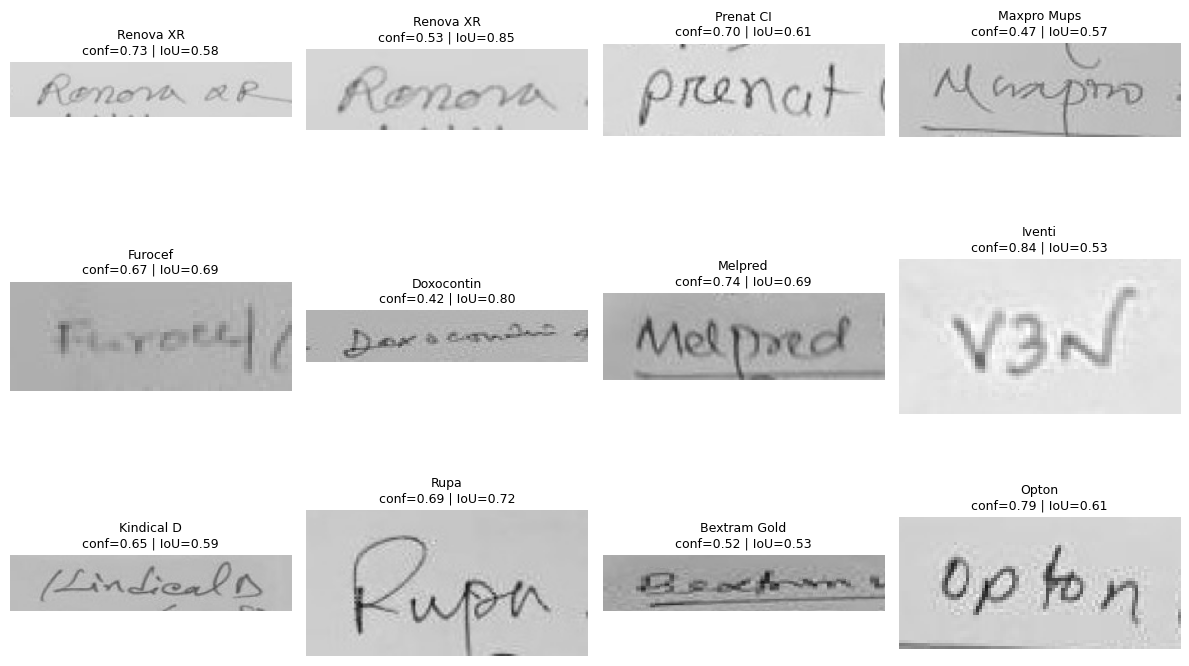

In [21]:
import matplotlib.pyplot as plt
import cv2

SHOW = 12
sample = df_pred.sample(min(SHOW, len(df_pred)), random_state=42).reset_index(drop=True)

plt.figure(figsize=(12, 8))
for i in range(len(sample)):
    cp = sample.loc[i, "crop_path"]
    conf = sample.loc[i, "conf"]
    nm   = sample.loc[i, "matched_name"]
    iou  = sample.loc[i, "match_iou"]

    img = cv2.imread(cp)
    if img is None:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 4, i+1)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"{nm}\nconf={conf:.2f} | IoU={iou:.2f}", fontsize=9)

plt.tight_layout()
plt.show()


In [22]:
!pip -q install torch torchvision torchaudio rapidfuzz tqdm pillow opencv-python pandas matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 51.9 MB/s eta 0:00:00


In [23]:
import os, glob

# Common candidates in Colab after Roboflow download
cands = []
for p in glob.glob("/content/*"):
    if os.path.isdir(p) and os.path.exists(os.path.join(p, "data.yaml")):
        cands.append(p)

print("Candidates with data.yaml:")
for p in cands:
    print(" -", p)

# If you know it's /content/Merged--1, set it directly:
ORIG_ROOT = "/content/Merged--1"
print("\nTrying ORIG_ROOT:", ORIG_ROOT, "exists:", os.path.exists(ORIG_ROOT))


Candidates with data.yaml:
 - /content/Merged--1
 - /content/Merged_ROI_1class

Trying ORIG_ROOT: /content/Merged--1 exists: True


In [24]:
import yaml, os

DATA_YAML_ORIG = os.path.join(ORIG_ROOT, "data.yaml")
assert os.path.exists(DATA_YAML_ORIG), f"❌ data.yaml not found at: {DATA_YAML_ORIG}"

with open(DATA_YAML_ORIG, "r") as f:
    data = yaml.safe_load(f)

names = data["names"]
if isinstance(names, dict):
    CLASS_NAMES = [names[i] for i in range(len(names))]
else:
    CLASS_NAMES = list(names)

print("✅ Classes:", len(CLASS_NAMES))
print("First 20:", CLASS_NAMES[:20])


✅ Classes: 1445
First 20: ['A to Z', 'A-C', 'A-Cal D', 'A-Calm', 'AMycin', 'ATOZ Senior', 'ATV', 'AU-20', 'Abdalan', 'Abdolax', 'Abecab', 'Abetis Plus', 'Abetis', 'Ace Plus', 'Ace Power', 'Ace XR', 'Ace', 'Acelex', 'Acetram', 'Acifix']


In [25]:
import os, glob, cv2
import pandas as pd
from tqdm import tqdm

OUT_CROP_ROOT = "/content/roboflow_gt_crops"
os.makedirs(OUT_CROP_ROOT, exist_ok=True)

def yolo_to_xyxy(xc, yc, w, h, W, H):
    x1 = int((xc - w/2) * W)
    y1 = int((yc - h/2) * H)
    x2 = int((xc + w/2) * W)
    y2 = int((yc + h/2) * H)
    # clip
    x1 = max(0, min(W-1, x1))
    y1 = max(0, min(H-1, y1))
    x2 = max(0, min(W-1, x2))
    y2 = max(0, min(H-1, y2))
    return x1, y1, x2, y2

def crop_from_split(split, pad=0.08):
    img_dir = os.path.join(ORIG_ROOT, split, "images")
    lbl_dir = os.path.join(ORIG_ROOT, split, "labels")
    assert os.path.isdir(img_dir), f"❌ Missing: {img_dir}"
    assert os.path.isdir(lbl_dir), f"❌ Missing: {lbl_dir}"

    out_dir = os.path.join(OUT_CROP_ROOT, split)
    os.makedirs(out_dir, exist_ok=True)

    rows = []
    imgs = sorted(glob.glob(os.path.join(img_dir, "*")))

    for img_path in tqdm(imgs, desc=f"Cropping {split}"):
        stem = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(lbl_dir, stem + ".txt")
        if not os.path.exists(lbl_path):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue
        H, W = img.shape[:2]

        with open(lbl_path, "r") as f:
            lines = [ln.strip().split() for ln in f if ln.strip()]

        for j, parts in enumerate(lines):
            if len(parts) < 5:
                continue
            cls = int(float(parts[0]))
            xc, yc, bw, bh = map(float, parts[1:5])

            x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, bw, bh, W, H)

            # padding
            px = int((x2 - x1) * pad)
            py = int((y2 - y1) * pad)
            x1p = max(0, x1 - px); y1p = max(0, y1 - py)
            x2p = min(W-1, x2 + px); y2p = min(H-1, y2 + py)

            if x2p <= x1p or y2p <= y1p:
                continue

            crop = img[y1p:y2p, x1p:x2p]
            cls_name = CLASS_NAMES[cls] if 0 <= cls < len(CLASS_NAMES) else str(cls)

            crop_path = os.path.join(out_dir, f"{stem}_gt_{j:03d}_c{cls}.jpg")
            cv2.imwrite(crop_path, crop)

            rows.append({
                "split": split,
                "orig_image": img_path,
                "label_file": lbl_path,
                "crop_path": crop_path,
                "cls_id": cls,
                "cls_name": cls_name,
                "x1": x1p, "y1": y1p, "x2": x2p, "y2": y2p
            })

    print(f"[{split}] ✅ Crops:", len(rows))
    return rows

all_rows = []
for split in ["train", "valid", "test"]:
    all_rows += crop_from_split(split, pad=0.08)

df_crops = pd.DataFrame(all_rows)
CSV_PATH = os.path.join(OUT_CROP_ROOT, "gt_crops_metadata.csv")
df_crops.to_csv(CSV_PATH, index=False)

print("\n✅ TOTAL crops:", len(df_crops))
print("✅ Saved:", CSV_PATH)
df_crops.head()


Cropping train: 100%|██████████| 622/622 [00:01<00:00, 359.26it/s]


[train] ✅ Crops: 2838


Cropping valid: 100%|██████████| 176/176 [00:00<00:00, 310.59it/s]


[valid] ✅ Crops: 799


Cropping test: 100%|██████████| 95/95 [00:00<00:00, 318.33it/s]


[test] ✅ Crops: 402

✅ TOTAL crops: 4039
✅ Saved: /content/roboflow_gt_crops/gt_crops_metadata.csv


,split,orig_image,label_file,crop_path,cls_id,cls_name,x1,y1,x2,y2
0,train,/content/Merged--1/train/images/20230314_20144...,/content/Merged--1/train/labels/20230314_20144...,/content/roboflow_gt_crops/train/20230314_2014...,90,Anuva,424,258,531,288
1,train,/content/Merged--1/train/images/20230314_20144...,/content/Merged--1/train/labels/20230314_20144...,/content/roboflow_gt_crops/train/20230314_2014...,1022,Paricel,453,348,549,374
2,train,/content/Merged--1/train/images/20230314_20144...,/content/Merged--1/train/labels/20230314_20144...,/content/roboflow_gt_crops/train/20230314_2014...,371,Deflux,442,393,558,430
3,train,/content/Merged--1/train/images/20230314_20144...,/content/Merged--1/train/labels/20230314_20144...,/content/roboflow_gt_crops/train/20230314_2014...,1218,Solas,457,471,530,496
4,train,/content/Merged--1/train/images/20230314_20144...,/content/Merged--1/train/labels/20230314_20144...,/content/roboflow_gt_crops/train/20230314_2014...,326,Coralcal DX,447,517,604,554


In [26]:
import os, glob
print("CSV exists:", os.path.exists("/content/roboflow_gt_crops/gt_crops_metadata.csv"))
print("Sample crops:", glob.glob("/content/roboflow_gt_crops/train/*.jpg")[:5])


CSV exists: True
Sample crops: ['/content/roboflow_gt_crops/train/340150386_568511691751207_8874639619233414358_n_jpg.rf.2290ae36a41d4d61327f6f99a4d522d3_gt_002_c608.jpg', '/content/roboflow_gt_crops/train/received_6298937343500299_jpeg.rf.9a48cb557dcdde5e64cac4e053e5eecb_gt_001_c461.jpg', '/content/roboflow_gt_crops/train/WhatsApp-Image-2023-04-12-at-12-48-16-AM_jpeg.rf.ceb5f3e454f60126ea359692b7429081_gt_000_c1207.jpg', '/content/roboflow_gt_crops/train/received_908109136938851_jpeg.rf.a58af36dc910fd69f5b7c7371ae74cb0_gt_003_c1061.jpg', '/content/roboflow_gt_crops/train/340460175_772521710891669_8498397083419418235_n_jpg.rf.1bd2f05b5b8f53c970f9c004c4d41651_gt_007_c373.jpg']


In [27]:
import os
import pandas as pd

GT_META = "/content/roboflow_gt_crops/gt_crops_metadata.csv"
assert os.path.exists(GT_META), f"❌ Not found: {GT_META}"

df = pd.read_csv(GT_META)

# text label = class name
df["text"] = df["cls_name"].astype(str).str.strip()

# keep valid
df = df[df["crop_path"].apply(os.path.exists)]
df = df[df["text"].str.len() > 0].reset_index(drop=True)

train_df = df[df["split"]=="train"][["crop_path","text"]].reset_index(drop=True)
val_df   = df[df["split"]=="valid"][["crop_path","text"]].reset_index(drop=True)
test_df  = df[df["split"]=="test"][["crop_path","text"]].reset_index(drop=True)

print("✅ OCR pairs:")
print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

train_df.head()


✅ OCR pairs:
Train: 2838
Val:   799
Test:  402


,crop_path,text
0,/content/roboflow_gt_crops/train/20230314_2014...,Anuva
1,/content/roboflow_gt_crops/train/20230314_2014...,Paricel
2,/content/roboflow_gt_crops/train/20230314_2014...,Deflux
3,/content/roboflow_gt_crops/train/20230314_2014...,Solas
4,/content/roboflow_gt_crops/train/20230314_2014...,Coralcal DX


In [28]:
#text normalization + build CTC vocabulary

import json

def normalize_text(s: str) -> str:
    s = str(s).lower().strip()
    s = " ".join(s.split())
    return s

# normalize all labels
train_df["text"] = train_df["text"].apply(normalize_text)
val_df["text"]   = val_df["text"].apply(normalize_text)
test_df["text"]  = test_df["text"].apply(normalize_text)

# build charset from TRAIN only
charset = set()
for t in train_df["text"].tolist():
    for ch in t:
        charset.add(ch)

# CTC requires blank at index 0
chars = ["[blank]"] + sorted(list(charset))
char2idx = {c:i for i,c in enumerate(chars)}
idx2char = {i:c for c,i in char2idx.items()}

print("✅ Vocab size:", len(chars))
print("Sample chars:", chars[:60])

# save vocab
VOCAB_PATH = "/content/ctc_vocab.json"
with open(VOCAB_PATH, "w", encoding="utf-8") as f:
    json.dump({"chars": chars}, f, ensure_ascii=False, indent=2)

print("✅ Saved vocab to:", VOCAB_PATH)


✅ Vocab size: 35
Sample chars: ['[blank]', ' ', '-', '0', '1', '2', '3', '4', '6', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
✅ Saved vocab to: /content/ctc_vocab.json


In [29]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

IMG_H = 32
MAX_W = 256   # increase to 320 if words get cut

def resize_pad_grayscale(pil_img, img_h=32, max_w=256):
    img = pil_img.convert("L")
    w, h = img.size
    new_w = int(w * (img_h / max(1, h)))
    new_w = max(1, min(new_w, max_w))
    img = img.resize((new_w, img_h), Image.BICUBIC)

    arr = np.array(img).astype(np.float32)

    if new_w < max_w:
        pad = 255 * np.ones((img_h, max_w - new_w), dtype=np.float32)
        arr = np.concatenate([arr, pad], axis=1)

    # normalize to [-1, 1]
    arr = (arr / 255.0 - 0.5) / 0.5
    return arr

class WordDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        img = Image.open(row["crop_path"]).convert("RGB")
        arr = resize_pad_grayscale(img, IMG_H, MAX_W)
        x = torch.tensor(arr).unsqueeze(0)  # (1,H,W)
        y = row["text"]
        return x, y

# sanity check
x0, y0 = WordDataset(train_df)[0]
print("✅ Example sample:", x0.shape, y0)


✅ Example sample: torch.Size([1, 32, 256]) anuva


In [30]:
class CTCEncoder:
    def __init__(self, char2idx, idx2char, blank_idx=0):
        self.char2idx = char2idx
        self.idx2char = idx2char
        self.blank_idx = blank_idx

    def encode(self, texts):
        targets = []
        lengths = []
        for t in texts:
            ids = [self.char2idx[ch] for ch in t if ch in self.char2idx]
            targets.extend(ids)
            lengths.append(len(ids))
        return torch.tensor(targets, dtype=torch.long), torch.tensor(lengths, dtype=torch.long)

    def greedy_decode(self, log_probs):
        # log_probs: (T,N,C)
        preds = log_probs.argmax(2).cpu().numpy()
        T, N = preds.shape
        out = []
        for n in range(N):
            seq = preds[:, n].tolist()
            s = []
            prev = None
            for p in seq:
                if p != self.blank_idx and p != prev:
                    s.append(self.idx2char[p])
                prev = p
            out.append("".join(s))
        return out

encoder = CTCEncoder(char2idx, idx2char, blank_idx=0)


In [31]:
BATCH = 64

train_loader = DataLoader(
    WordDataset(train_df),
    batch_size=BATCH,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    WordDataset(val_df),
    batch_size=BATCH,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    WordDataset(test_df),
    batch_size=BATCH,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("✅ Batches:",
      len(train_loader),
      len(val_loader),
      len(test_loader))


✅ Batches: 45 13 7


In [32]:
import torch.nn as nn

class BiLSTM(nn.Module):
    def __init__(self, nIn, nHidden, nOut):
        super().__init__()
        self.rnn = nn.LSTM(nIn, nHidden, bidirectional=True)
        self.fc = nn.Linear(nHidden*2, nOut)

    def forward(self, x):
        y, _ = self.rnn(x)
        T, N, H2 = y.size()
        y = self.fc(y.reshape(T*N, H2)).reshape(T, N, -1)
        return y

class CRNN(nn.Module):
    def __init__(self, nclass, nh=256):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, 1, 1), nn.ReLU(True),
            nn.Conv2d(256, 256, 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d((2, 1), (2, 1)),

            nn.Conv2d(256, 512, 3, 1, 1), nn.BatchNorm2d(512), nn.ReLU(True),
            nn.Conv2d(512, 512, 3, 1, 1), nn.BatchNorm2d(512), nn.ReLU(True),
            nn.MaxPool2d((2, 1), (2, 1)),

            nn.Conv2d(512, 512, 2, 1, 0), nn.ReLU(True)
        )

        self.rnn = nn.Sequential(
            BiLSTM(512, nh, nh),
            BiLSTM(nh, nh, nclass)
        )

    def forward(self, x):
        conv = self.cnn(x)            # (N,512,1,W')
        conv = conv.squeeze(2)        # (N,512,W')
        conv = conv.permute(2, 0, 1)  # (T,N,512)
        out = self.rnn(conv)          # (T,N,C)
        return out.log_softmax(2)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = CRNN(nclass=len(chars)).to(device)

ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("✅ Model ready on:", device)


✅ Model ready on: cuda


In [33]:
from rapidfuzz.distance import Levenshtein

def cer(pred, gt):
    if len(gt) == 0:
        return 0 if len(pred) == 0 else 1
    return Levenshtein.distance(pred, gt) / max(1, len(gt))

@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss, total_cer, total, exact = 0.0, 0.0, 0, 0

    for imgs, texts in loader:
        imgs = imgs.to(device)
        texts = list(texts)

        log_probs = model(imgs)
        T, N, C = log_probs.shape
        input_lengths = torch.full((N,), T, dtype=torch.long)

        targets, target_lengths = encoder.encode(texts)
        loss = ctc_loss(log_probs, targets, input_lengths, target_lengths)

        preds = encoder.greedy_decode(log_probs)
        for p, g in zip(preds, texts):
            p = normalize_text(p)
            g = normalize_text(g)
            total_cer += cer(p, g)
            exact += int(p == g)
            total += 1

        total_loss += loss.item() * N

    return {
        "loss": total_loss / max(1, total),
        "cer": total_cer / max(1, total),
        "word_acc": exact / max(1, total)
    }

print("✅ Sanity val check:", evaluate(val_loader))


✅ Sanity val check: {'loss': 29.892486104380353, 'cer': 0.9636641518681569, 'word_acc': 0.0}


In [34]:
from tqdm import tqdm
import torch

EPOCHS = 50
BEST_PATH = "/content/best_crnn_medicine_ocr.pth"
best_val_cer = 1e9

for epoch in range(1, EPOCHS + 1):
    model.train()
    running, seen = 0.0, 0

    for imgs, texts in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
        imgs = imgs.to(device)
        texts = list(texts)

        log_probs = model(imgs)
        T, N, C = log_probs.shape
        input_lengths = torch.full((N,), T, dtype=torch.long)

        targets, target_lengths = encoder.encode(texts)
        loss = ctc_loss(log_probs, targets, input_lengths, target_lengths)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        running += loss.item() * N
        seen += N

    train_loss = running / max(1, seen)
    val_metrics = evaluate(val_loader)

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_CER={val_metrics['cer']:.4f} | "
        f"val_acc={val_metrics['word_acc']:.4f}"
    )

    if val_metrics["cer"] < best_val_cer:
        best_val_cer = val_metrics["cer"]
        torch.save({
            "model": model.state_dict(),
            "chars": chars,
            "IMG_H": IMG_H,
            "MAX_W": MAX_W
        }, BEST_PATH)
        print("✅ Saved BEST model | CER:", best_val_cer)


Epoch 1/50: 100%|██████████| 45/45 [00:06<00:00,  7.34it/s]


Epoch 001 | train_loss=4.6583 | val_loss=3.3075 | val_CER=1.0000 | val_acc=0.0000
✅ Saved BEST model | CER: 1.0


Epoch 2/50: 100%|██████████| 45/45 [00:05<00:00,  8.73it/s]


Epoch 002 | train_loss=3.3085 | val_loss=3.2917 | val_CER=1.0000 | val_acc=0.0000


Epoch 3/50: 100%|██████████| 45/45 [00:05<00:00,  8.47it/s]


...

Epoch 048 | train_loss=2.9066 | val_loss=2.9760 | val_CER=0.8463 | val_acc=0.0000


Epoch 49/50: 100%|██████████| 45/45 [00:05<00:00,  8.55it/s]


Epoch 049 | train_loss=2.9031 | val_loss=2.9600 | val_CER=0.8598 | val_acc=0.0000


Epoch 50/50: 100%|██████████| 45/45 [00:05<00:00,  8.45it/s]


Epoch 050 | train_loss=2.8968 | val_loss=2.9318 | val_CER=0.8496 | val_acc=0.0000


In [35]:
ckpt = torch.load(BEST_PATH, map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()

print("✅ TEST metrics:", evaluate(test_loader))


✅ TEST metrics: {'loss': 2.966876103510311, 'cer': 0.8313448022403247, 'word_acc': 0.0}


In [36]:
import torch, os

BEST_PATH = "/content/best_crnn_medicine_ocr.pth"
assert os.path.exists(BEST_PATH), f"❌ Not found: {BEST_PATH}"

ckpt = torch.load(BEST_PATH, map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()

print("✅ Loaded best OCR model.")


✅ Loaded best OCR model.


In [37]:
from rapidfuzz import process, fuzz

lexicon = sorted(set(train_df["text"].tolist()))
print("✅ Lexicon size:", len(lexicon))

def lexicon_correct(pred, lexicon, threshold=70):
    pred = normalize_text(pred)
    if not pred:
        return ""
    m = process.extractOne(pred, lexicon, scorer=fuzz.ratio)
    if m is None:
        return pred
    match, score, _ = m
    return match if score >= threshold else pred


✅ Lexicon size: 1185


🖼 Crop: /content/roboflow_gt_crops/test/WhatsApp-Image-2023-04-12-at-12-22-15-PM_jpeg.rf.3138dad0be34f2c8e1051131070d9b7a_gt_001_c1174.jpg
✅ GT: rosuva
🔤 Pred (raw): eroro
🔤 Pred (norm): eroro
🧠 Pred (lexicon): eroro


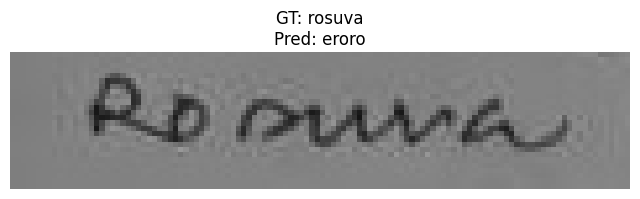

In [38]:
import random
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

def preprocess_crop_for_model(path):
    bgr = cv2.imread(path)
    if bgr is None:
        return None, None
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    pil = Image.fromarray(rgb)

    arr = resize_pad_grayscale(pil, IMG_H, MAX_W)
    x = torch.tensor(arr).unsqueeze(0).unsqueeze(0).to(device)  # (1,1,H,W)
    return rgb, x

@torch.no_grad()
def predict_text(path):
    rgb, x = preprocess_crop_for_model(path)
    if x is None:
        return None, "", "", ""
    log_probs = model(x)  # (T,1,C)
    pred = encoder.greedy_decode(log_probs)[0]
    pred_norm = normalize_text(pred)
    pred_corr = lexicon_correct(pred_norm, lexicon, threshold=70)
    return rgb, pred, pred_norm, pred_corr

# pick one random test crop
row = test_df.sample(1, random_state=None).iloc[0]
crop_path = row["crop_path"]
gt_text = row["text"]

rgb, pred_raw, pred_norm, pred_corr = predict_text(crop_path)

print("🖼 Crop:", crop_path)
print("✅ GT:", gt_text)
print("🔤 Pred (raw):", pred_raw)
print("🔤 Pred (norm):", pred_norm)
print("🧠 Pred (lexicon):", pred_corr)

plt.figure(figsize=(8,3))
plt.imshow(rgb)
plt.axis("off")
plt.title(f"GT: {gt_text}\nPred: {pred_corr}", fontsize=12)
plt.show()


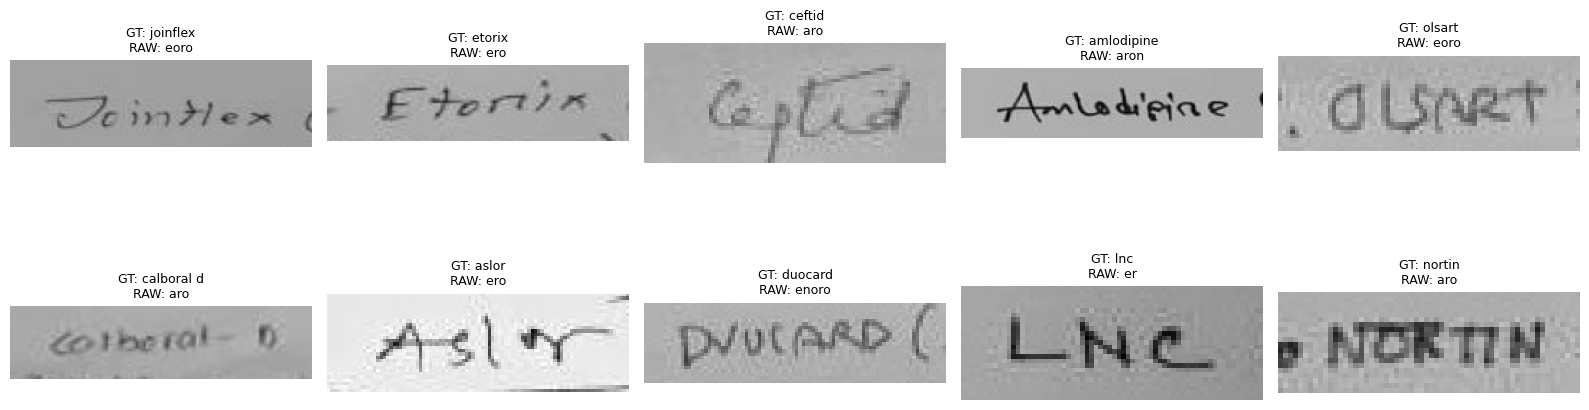

In [39]:
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import torch
import random

def preprocess_crop_raw(path):
    bgr = cv2.imread(path)
    if bgr is None:
        return None, None
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    pil = Image.fromarray(rgb)

    arr = resize_pad_grayscale(pil, IMG_H, MAX_W)
    x = torch.tensor(arr).unsqueeze(0).unsqueeze(0).to(device)
    return rgb, x

@torch.no_grad()
def predict_raw_only(path):
    rgb, x = preprocess_crop_raw(path)
    if x is None:
        return None, ""
    log_probs = model(x)
    pred = encoder.greedy_decode(log_probs)[0]
    return rgb, pred

# show 10 random test samples
sample = test_df.sample(10, random_state=42).reset_index(drop=True)

plt.figure(figsize=(16,6))
for i in range(len(sample)):
    row = sample.loc[i]
    rgb, pred = predict_raw_only(row["crop_path"])

    plt.subplot(2,5,i+1)
    plt.imshow(rgb)
    plt.axis("off")
    plt.title(f"GT: {row['text']}\nRAW: {pred}", fontsize=9)

plt.tight_layout()
plt.show()


In [40]:
import os, torch

print("BEST exists:", os.path.exists(BEST_PATH), BEST_PATH)

ckpt = torch.load(BEST_PATH, map_location=device)
print("Checkpoint keys:", ckpt.keys())
print("Vocab size in ckpt:", len(ckpt["chars"]))
print("IMG_H ckpt:", ckpt.get("IMG_H"), "MAX_W ckpt:", ckpt.get("MAX_W"))

model.load_state_dict(ckpt["model"])
model.eval()
print("✅ Loaded weights into model")


BEST exists: True /content/best_crnn_medicine_ocr.pth
Checkpoint keys: dict_keys(['model', 'chars', 'IMG_H', 'MAX_W'])
Vocab size in ckpt: 35
IMG_H ckpt: 32 MAX_W ckpt: 256
✅ Loaded weights into model
